<a href="https://colab.research.google.com/github/alxmzr/Colab/blob/main/Bollinger_Band_Strategy_with_Stop_Loss_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Implementing a Bollinger Band Strategy with Stop Loss in Python (Algorithmic Trading)
# https://medium.com/@chris_42047/implementing-a-bolling-band-strategy-with-stop-loss-in-python-algorithmic-trading-d9d3fd0c3787

In [2]:
!pip install pandas_ta ta

import os
import math
import numpy as np
import pandas as pd
import datetime
import time
import random
from datetime import date
import pandas_ta as ta
from ta.volatility import BollingerBands
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import yfinance as yf
import datetime
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay
US_BUSINESS_DAY = CustomBusinessDay(calendar=USFederalHolidayCalendar())

In [3]:
def load_historic_data(symbol):
    today = datetime.date.today()
    start_date = today - (251 * US_BUSINESS_DAY)

    try:
        df = yf.download(symbol, start=start_date, end=today, progress=False)
        if df.empty:
            return None

        # Handle MultiIndex columns by extracting the first level (e.g., 'Close')
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        # Standardize column names to lowercase for the strategy logic
        df.columns = [str(col).lower() for col in df.columns]
        return df
    except Exception as e:
        print(f'Error loading stock data for {symbol}: {e}')
        return None

In [4]:
# Test data loading again to verify the fix
test_symbol = 'AAPL'
df_test = load_historic_data(test_symbol)
if df_test is not None and not df_test.empty:
    print(f'Successfully loaded {len(df_test)} rows for {test_symbol}')
    # Ensure required columns are present after MultiIndex handling
    if 'close' in df_test.columns:
        print('Columns found:', df_test.columns.tolist())
        display(df_test.head())
    else:
        print(f'Warning: Expected column "close" not found. Found: {df_test.columns.tolist()}')
else:
    print(f'Failed to load data for {test_symbol}')

/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Successfully loaded 252 rows for AAPL
Columns found: ['close', 'high', 'low', 'open', 'volume']


,close,high,low,open,volume
Date,,,,,
2025-05-06,197.648575,199.779288,196.165050,197.349889,51216500
2025-05-07,195.398376,198.574536,192.411395,198.305703,68536700
2025-05-08,196.632996,199.181884,193.835177,196.861993,50478900
2025-05-09,197.668472,199.669744,196.682763,198.136434,36453900
2025-05-12,210.150482,210.629037,206.122746,210.329944,63775800


In [5]:
def calculate_bollinger_bands(df, window=20):
    # Initialize Bollinger Bands Indicator
    # Default window is 20, but now it can be parameterized
    indicator_bb = BollingerBands(close=df["close"], window=window, window_dev=2)

    # Add Bollinger Bands features
    df['BB_mid'] = indicator_bb.bollinger_mavg()
    df['BB_high'] = indicator_bb.bollinger_hband()
    df['BB_low'] = indicator_bb.bollinger_lband()

    return df

In [6]:
def apply_strategy_rules(df):
    #  Entry Rule 1: Close price below Low Bollinger Band
    df['BB_entry_signal'] = np.where((df["close"] < df["BB_low"]) & (df["close"].shift() >= df["BB_low"]), 1, 0)

    #  Exit rule
    df['BB_exit_signal'] = np.where((df["close"] > df["BB_high"]) & (df["close"].shift() <= df["BB_high"]), 1, 0)

    return df

In [7]:
def execute_strategy(df):
    close_prices = df['close']
    BB_entry_signals = df['BB_entry_signal']
    BB_exit_signals = df['BB_exit_signal']
    entry_prices = []
    exit_prices = []
    entry_signal = 0
    exit_signal = 0
    buy_price = -1
    hold = 0

    for i in range(len(close_prices)):
        #  Check entry and exit signals
        if BB_entry_signals[i] == 1:
            entry_signal = 1
        else:
            entry_signal = 0
        if BB_exit_signals[i] == 1:
            exit_signal = 1
        else:
            exit_signal = 0

        #  Add entry prices
        if hold == 0 and entry_signal == 1:
            buy_price = close_prices[i]
            entry_prices.append(close_prices[i])
            exit_prices.append(np.nan)
            entry_signal = 0
            hold = 1
        #  Evaluate exit strategy
        elif (hold == 1 and exit_signal == 1 or (hold == 1 and close_prices[i] <= buy_price * 0.95)):
            entry_prices.append(np.nan)
            exit_prices.append(close_prices[i])
            exit_signal = 0
            buy_price = -1
            hold = 0
        else:
            #  Neither entry nor exit
            entry_prices.append(np.nan)
            exit_prices.append(np.nan)

    return entry_prices, exit_prices

In [8]:
def plot_graph(df, entry_prices, exit_prices):
    bb_high = df['BB_high']
    bb_mid = df['BB_mid']
    bb_low = df['BB_low']
    fig = make_subplots(rows=1, cols=1)

    #  Plot close price
    fig.add_trace(go.Line(x = df.index, y = df['close'], line=dict(color="blue", width=1), name="Close"), row = 1, col = 1)

    #  Plot bollinger bands
    fig.add_trace(go.Line(x = df.index, y = bb_high, line=dict(color="#ffdf80", width=1), name="BB High"), row = 1, col = 1)
    fig.add_trace(go.Line(x = df.index, y = bb_mid, line=dict(color="#ffd866", width=1), name="BB Mid"), row = 1, col = 1)
    fig.add_trace(go.Line(x = df.index, y = bb_low, line=dict(color="#ffd24d", width=1), name="BB Low"), row = 1, col = 1)

    #  Add buy and sell indicators
    fig.add_trace(go.Scatter(x=df.index, y=entry_prices, marker_symbol="arrow-up", marker=dict(
        color='green',
    ),mode='markers',name='Buy'))
    fig.add_trace(go.Scatter(x=df.index, y=exit_prices, marker_symbol="arrow-down", marker=dict(
        color='red'
    ),mode='markers',name='Sell'))

    fig.update_layout(
        title={'text':'BB + Stop Loss', 'x':0.5},
        autosize=False,
        width=800,height=400)
    fig.update_yaxes(range=[0,1000000000],secondary_y=True)
    fig.update_yaxes(visible=False, secondary_y=True)  #hide range slider

    fig.show()

In [9]:
def calculate_buy_hold_profit(investment, df):
    close_prices = df['close']
    buy_quantity = investment / close_prices[0]
    sell_amount = buy_quantity * close_prices[len(close_prices)-1]
    profit = sell_amount - investment
    return profit

In [10]:
def calculate_strategy_profit(investment, entry_prices, exit_prices):
    entry_price = 0
    hold = 0
    total_profit = 0
    quantity = 0
    available_funds = investment
    purchase_amount = 0

    for i in range(len(entry_prices)):
        current_entry_price = entry_prices[i]
        current_exit_price = exit_prices[i]

        if not math.isnan(current_entry_price) and hold == 0:
            entry_price = current_entry_price
            quantity = available_funds / entry_price
            purchase_amount = quantity * entry_price
            hold = 1
        elif hold == 1 and not math.isnan(current_exit_price):
            hold = 0
            sales_amount = quantity * current_exit_price
            profit_or_loss = sales_amount - purchase_amount
            available_funds = available_funds + profit_or_loss
            total_profit += profit_or_loss

    return total_profit

In [11]:
def perform_analysis(symbol, df, investment, window=20):
    df = df.reset_index()
    df = calculate_bollinger_bands(df, window=window)
    df = apply_strategy_rules(df)

    entry_prices, exit_prices = execute_strategy(df)
    profit_or_loss = calculate_strategy_profit(investment, entry_prices, exit_prices)
    buy_hold_profit = calculate_buy_hold_profit(investment, df)
    return profit_or_loss, buy_hold_profit

In [12]:
# Backtesting using NASDAQ 100
nasdaq_100_df = pd.read_csv('https://raw.githubusercontent.com/justmobiledev/python-algorithmic-trading/main/data/nasdaq_100.csv')
nasdaq_100 = nasdaq_100_df['Symbol'].to_numpy()

In [13]:
#  Backtesting
total_strategy_profit = 0
total_buy_hold_profit = 0
successful_symbols = 0

for symbol in nasdaq_100:
    df = load_historic_data(symbol)
    if df is None or df.empty or len(df) < 20:
        continue

    #  Random interval between remote fetch to avoid spam issues
    random_secs = random.uniform(0.1, 0.5)
    time.sleep(random_secs)

    #  Run backtest
    investment = 10000
    try:
        # The analysis function handles resetting the index internally
        profit, buy_hold_profit = perform_analysis(symbol, df, investment=investment)
        print(f"Backtest profit for symbol {symbol}: ${math.trunc(profit)}, buy & hold: ${math.trunc(buy_hold_profit)}")
        total_strategy_profit += profit
        total_buy_hold_profit += buy_hold_profit
        successful_symbols += 1
    except Exception as e:
        print(f"Could not process {symbol}: {e}")
        continue

if successful_symbols > 0:
    print(f"\nAvg strategy profit per stock ({successful_symbols} stocks): ${math.trunc(total_strategy_profit / successful_symbols)}")
    print(f"Avg buy & hold profit per stock: ${math.trunc(total_buy_hold_profit / successful_symbols)}")
else:
    print("No symbols were successfully processed.")

/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Backtest profit for symbol AAPL: $451, buy & hold: $4546
Backtest profit for symbol ABNB: $2723, buy & hold: $1496


/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Backtest profit for symbol ADBE: $-1003, buy & hold: $-3467


/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


...

Backtest profit for symbol XEL: $-21, buy & hold: $1694


/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['XLNX']: YFTzMissingError('possibly delisted; no timezone found')
/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Backtest profit for symbol ZM: $2256, buy & hold: $3469


/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


Backtest profit for symbol ZS: $-3721, buy & hold: $-4044

Avg strategy profit per stock (95 stocks): $455
Avg buy & hold profit per stock: $3861


In [14]:
# Running backtest with a custom window size (e.g., 10)
TEST_WINDOW = 10
total_strategy_profit_10 = 0
total_buy_hold_profit_10 = 0
successful_symbols_10 = 0

# Using a smaller subset for quick verification or the whole list
for symbol in nasdaq_100[:20]:
    df = load_historic_data(symbol)
    if df is None or df.empty or len(df) < TEST_WINDOW:
        continue

    try:
        profit, buy_hold_profit = perform_analysis(symbol, df, investment=10000, window=TEST_WINDOW)
        total_strategy_profit_10 += profit
        total_buy_hold_profit_10 += buy_hold_profit
        successful_symbols_10 += 1
    except Exception:
        continue

if successful_symbols_10 > 0:
    print(f'Results for Window Size {TEST_WINDOW}:')
    print(f'Avg strategy profit: ${math.trunc(total_strategy_profit_10 / successful_symbols_10)}')
    print(f'Avg buy & hold profit: ${math.trunc(total_buy_hold_profit_10 / successful_symbols_10)}')
else:
    print('No data processed.')

/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=t

Results for Window Size 10:
Avg strategy profit: $1530
Avg buy & hold profit: $5946


/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/tmp/ipykernel_36053/2626836916.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=t

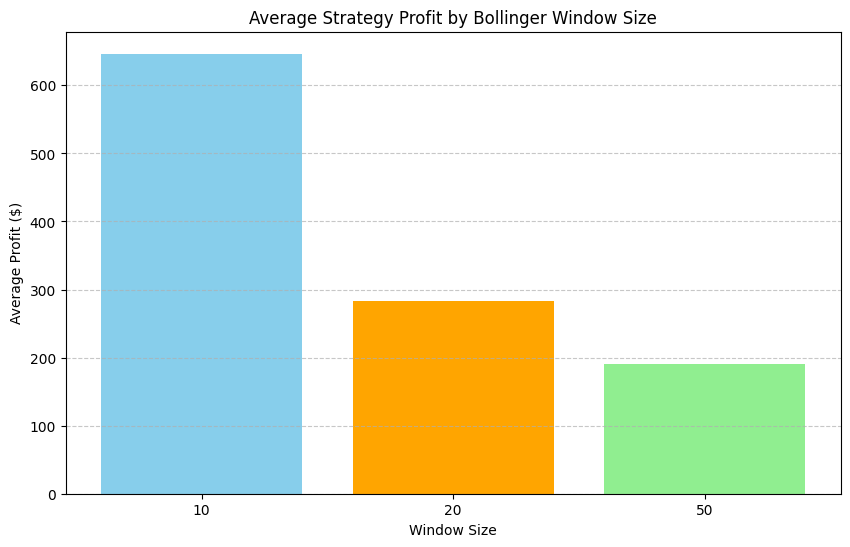

Window 10: Average Profit = $646.53
Window 20: Average Profit = $282.79
Window 50: Average Profit = $190.79


In [15]:
window_sizes = [10, 20, 50]
results = {}
subset_symbols = nasdaq_100[:30] # Using a subset for faster comparison

for w in window_sizes:
    total_prof = 0
    count = 0
    for symbol in subset_symbols:
        df_symbol = load_historic_data(symbol)
        if df_symbol is not None and len(df_symbol) > w:
            try:
                prof, _ = perform_analysis(symbol, df_symbol, investment=10000, window=w)
                total_prof += prof
                count += 1
            except:
                continue
    results[w] = total_prof / count if count > 0 else 0

# Visualize the comparison
plt.figure(figsize=(10, 6))
plt.bar([str(w) for w in results.keys()], results.values(), color=['skyblue', 'orange', 'lightgreen'])
plt.title('Average Strategy Profit by Bollinger Window Size')
plt.xlabel('Window Size')
plt.ylabel('Average Profit ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

for w, avg_prof in results.items():
    print(f'Window {w}: Average Profit = ${avg_prof:.2f}')

/tmp/ipykernel_36053/587504578.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/tmp/ipykernel_36053/587504578.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/tmp/ipykernel_36053/587504578.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=t

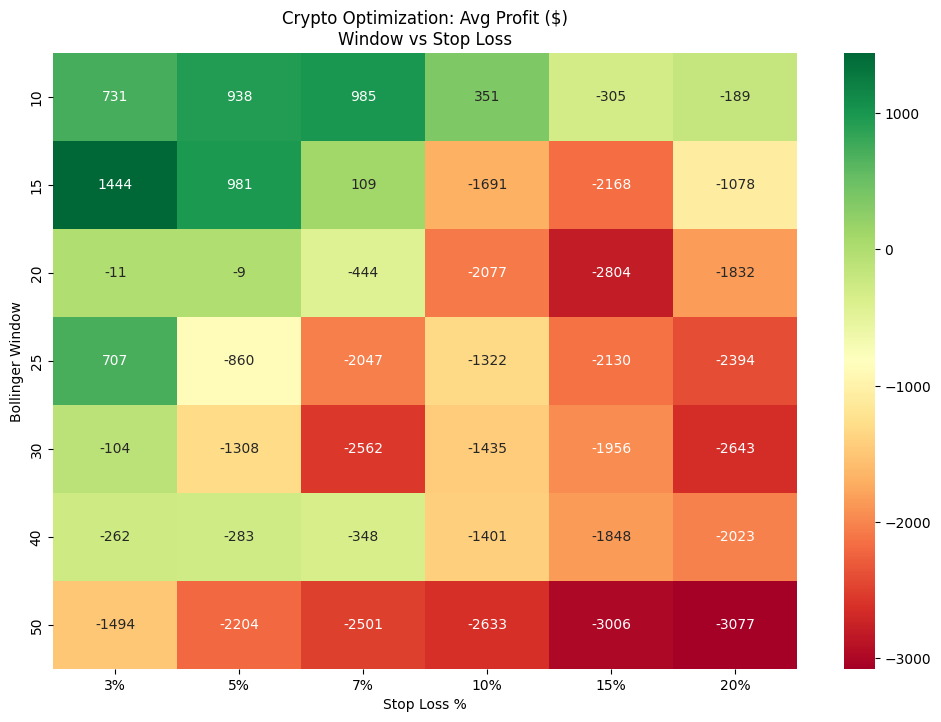

In [17]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime

# Список популярных криптовалют для исследования
crypto_symbols = ['BTC-USD', 'ETH-USD', 'SOL-USD', 'BNB-USD', 'ADA-USD', 'XRP-USD', 'DOT-USD', 'LINK-USD']

def load_crypto_data(symbol):
    today = datetime.date.today()
    start_date = today - datetime.timedelta(days=365) # 1 год данных
    try:
        df = yf.download(symbol, start=start_date, end=today, progress=False)
        if df.empty: return None
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df.columns = [str(col).lower() for col in df.columns]
        return df
    except Exception: return None

def crypto_grid_search(symbols, windows, stop_losses):
    results_matrix = np.zeros((len(windows), len(stop_losses)))
    data_cache = {}
    for symbol in symbols:
        df = load_crypto_data(symbol)
        if df is not None: data_cache[symbol] = df

    for i, w in enumerate(windows):
        for j, sl in enumerate(stop_losses):
            total_profit = 0
            count = 0
            for symbol, df_orig in data_cache.items():
                df = df_orig.copy().reset_index()
                df = calculate_bollinger_bands(df, window=w)
                df = apply_strategy_rules(df)

                close_prices = df['close']
                entry_sigs = df['BB_entry_signal']
                exit_sigs = df['BB_exit_signal']

                hold, buy_p, current_funds = 0, -1, 10000
                for t in range(len(close_prices)):
                    if hold == 0 and entry_sigs.iloc[t] == 1:
                        buy_p, hold = close_prices.iloc[t], 1
                    elif hold == 1 and (exit_sigs.iloc[t] == 1 or close_prices.iloc[t] <= buy_p * (1 - sl)):
                        current_funds *= (1 + (close_prices.iloc[t] - buy_p) / buy_p)
                        hold = 0
                total_profit += (current_funds - 10000)
                count += 1
            results_matrix[i, j] = total_profit / count if count > 0 else 0
    return results_matrix

# Параметры для теста на крипто
crypto_test_windows = [10, 15, 20, 25, 30, 40, 50]
crypto_test_stop_losses = [0.03, 0.05, 0.07, 0.10, 0.15, 0.20]

matrix_crypto = crypto_grid_search(crypto_symbols, crypto_test_windows, crypto_test_stop_losses)

plt.figure(figsize=(12, 8))
sns.heatmap(matrix_crypto, annot=True, fmt=".0f",
            xticklabels=[f"{int(x*100)}%" for x in crypto_test_stop_losses],
            yticklabels=crypto_test_windows, cmap='RdYlGn')
plt.title('Crypto Optimization: Avg Profit ($)\nWindow vs Stop Loss')
plt.xlabel('Stop Loss %')
plt.ylabel('Bollinger Window')
plt.show()

### Детальный анализ прибыльности с оптимальными параметрами
На основе данных тепловой карты мы выберем комбинацию окна Боллинджера и стоп-лосса, которая показала максимальную среднюю прибыль, и применим её к нашему портфелю криптовалют.

--- Лучшие параметры для крипторынка ---
Окно Боллинджера: 15
Уровень Стоп-лосса: 3%
Макс. средняя прибыль: $1444.18



/tmp/ipykernel_36053/587504578.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/tmp/ipykernel_36053/587504578.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=today, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/tmp/ipykernel_36053/587504578.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=t

,Symbol,Strategy Profit,Buy & Hold Profit,Diff (%)
0,BTC-USD,$4562.10,$-1608.21,61.7%
1,ETH-USD,$5333.08,$2976.34,23.6%
2,SOL-USD,$2399.99,$-3944.52,63.4%
3,BNB-USD,$981.21,$734.22,2.5%
4,ADA-USD,$-3697.74,$-6026.24,23.3%
5,XRP-USD,$-2641.78,$-3299.13,6.6%
6,DOT-USD,$-5.44,$-6676.80,66.7%
7,LINK-USD,$913.48,$-2767.92,36.8%


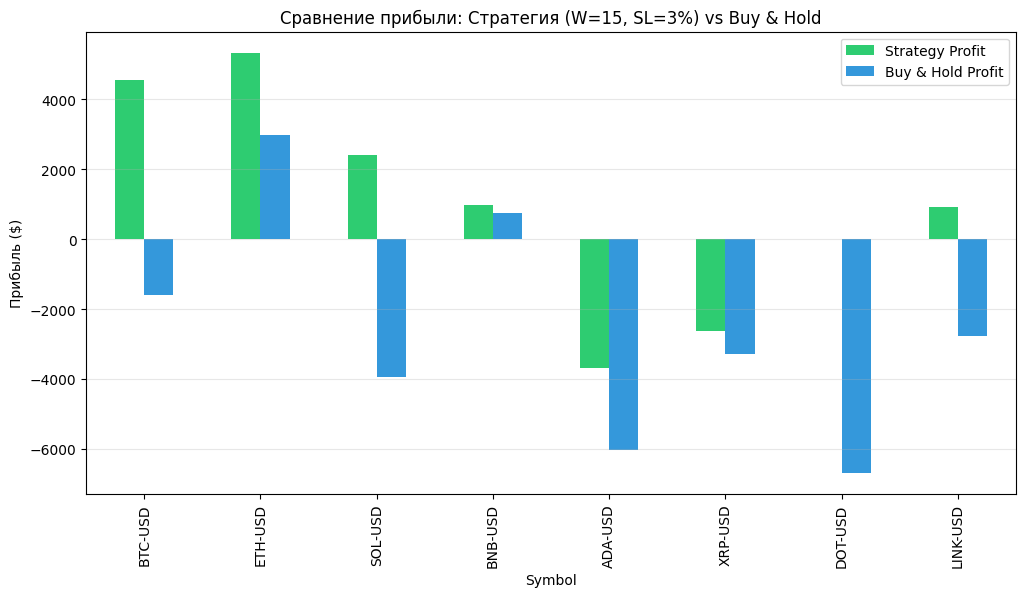

In [18]:
# 1. Поиск лучших параметров из матрицы результатов
# matrix_crypto имеет оси: строки=windows, столбцы=stop_losses
idx_win, idx_sl = np.unravel_index(np.argmax(matrix_crypto, axis=None), matrix_crypto.shape)
best_win = crypto_test_windows[idx_win]
best_sl = crypto_test_stop_losses[idx_sl]

print(f"--- Лучшие параметры для крипторынка ---")
print(f"Окно Боллинджера: {best_win}")
print(f"Уровень Стоп-лосса: {int(best_sl*100)}%")
print(f"Макс. средняя прибыль: ${matrix_crypto[idx_win, idx_sl]:.2f}\n")

# 2. Детальный бэктест для каждой монеты
final_results = []
investment = 10000

for symbol in crypto_symbols:
    df = load_crypto_data(symbol)
    if df is not None:
        # Очистка индекса для корректной работы индикаторов
        df = df.reset_index()
        df = calculate_bollinger_bands(df, window=best_win)
        df = apply_strategy_rules(df)

        # Выполнение стратегии
        entry_p, exit_p = execute_strategy(df)

        # Расчет прибыли
        strategy_profit = calculate_strategy_profit(investment, entry_p, exit_p)
        bh_profit = calculate_buy_hold_profit(investment, df)

        final_results.append({
            'Symbol': symbol,
            'Strategy Profit': strategy_profit,
            'Buy & Hold Profit': bh_profit,
            'Diff (%)': ((strategy_profit - bh_profit) / investment) * 100
        })

# 3. Визуализация сравнения
results_df = pd.DataFrame(final_results)
display(results_df.style.format({'Strategy Profit': '${:.2f}', 'Buy & Hold Profit': '${:.2f}', 'Diff (%)': '{:.1f}%'}))

# График
results_df.set_index('Symbol')[['Strategy Profit', 'Buy & Hold Profit']].plot(kind='bar', figsize=(12,6), color=['#2ecc71', '#3498db'])
plt.title(f'Сравнение прибыли: Стратегия (W={best_win}, SL={int(best_sl*100)}%) vs Buy & Hold')
plt.ylabel('Прибыль ($)')
plt.grid(axis='y', alpha=0.3)
plt.show()